# Solar Power Anomaly Detection - ML & Deep Learning Training (PyTorch)

**Approach:** Train models to predict solar generation from weather inputs (irradiance, temperature).  
**Anomaly = when actual generation deviates significantly from prediction**

## Models Implemented

### Machine Learning
1. **Isolation Forest** - unsupervised anomaly detection
2. **Random Forest Regression** - prediction-based anomaly detection

### Deep Learning (PyTorch)
3. **LSTM** - sequential prediction
4. **CNN-LSTM** - convolutional + sequential
5. **LSTM Autoencoder** - reconstruction-based anomaly detection
6. **Transformer** - attention-based prediction

### Anomaly Threshold
- **3-sigma rule:** anomaly if |prediction_error| > mean + 3*std

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import IsolationForest, RandomForestRegressor

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version: {torch.__version__}')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch version: 2.9.1+cu126
Device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti


## 1. Load Cleaned Data

In [2]:
# Load the cleaned data from EDA step
# Run 01_EDA.ipynb first to generate this file
df = pd.read_csv('datasets/site_1_cleaned.csv', index_col='datetime', parse_dates=True)

print(f'Data shape: {df.shape}')
print(f'Date range: {df.index.min()} to {df.index.max()}')
print(f'Columns: {list(df.columns)}')
df.head()

Data shape: (15013, 4)
Date range: 2025-06-01 01:00:00 to 2025-12-01 23:45:00
Columns: ['generation_kw', 'irradiance_wm2', 'temperature_c', 'load_kw']


,generation_kw,irradiance_wm2,temperature_c,load_kw
datetime,,,,
2025-06-01 01:00:00,0.0,0.0,24.8,274.0
2025-06-01 01:15:00,0.0,0.0,24.8,273.0
2025-06-01 01:30:00,0.0,0.0,24.8,284.0
2025-06-01 01:45:00,0.0,0.0,24.8,261.0
2025-06-01 02:00:00,0.0,0.0,24.8,270.0


In [3]:
FEATURES = ['irradiance_wm2', 'temperature_c']
TARGET = 'generation_kw'
ALL_COLS = FEATURES + [TARGET]

df_model = df[ALL_COLS].copy()
print(f'Modeling data: {df_model.shape}')
df_model.describe()

Modeling data: (15013, 3)


,irradiance_wm2,temperature_c,generation_kw
count,15013.000000,15013.000000,15013.000000
mean,157.764467,28.731106,96.532757
std,243.956976,3.010242,150.864929
min,0.000000,0.000000,0.000000
25%,0.000000,26.960000,0.000000
50%,0.000000,28.537500,2.000000
75%,259.615385,30.600000,159.000000
max,1073.000000,37.050000,638.000000


## 2. Train/Test Split (Time-Based)

Train: (10509, 3) (2025-06-01 01:00:00 to 2025-10-06 08:45:00)
Test : (4504, 3) (2025-10-06 09:00:00 to 2025-12-01 23:45:00)


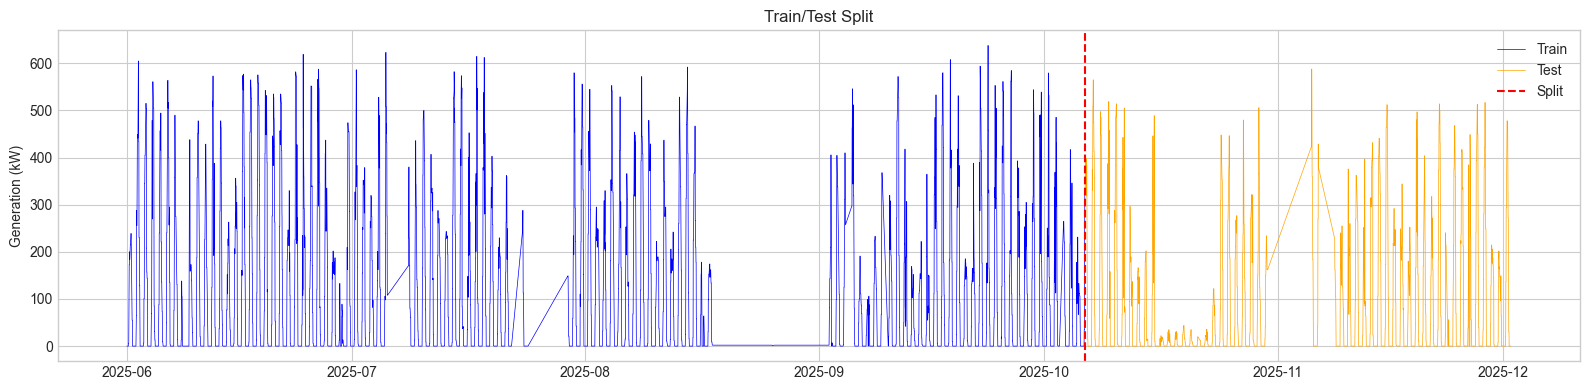

In [4]:
TRAIN_RATIO = 0.7
split_idx = int(len(df_model) * TRAIN_RATIO)

train_df = df_model.iloc[:split_idx]
test_df = df_model.iloc[split_idx:]

print(f'Train: {train_df.shape} ({train_df.index.min()} to {train_df.index.max()})')
print(f'Test : {test_df.shape} ({test_df.index.min()} to {test_df.index.max()})')

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(train_df.index, train_df[TARGET], color='blue', linewidth=0.5, label='Train')
ax.plot(test_df.index, test_df[TARGET], color='orange', linewidth=0.5, label='Test')
ax.axvline(test_df.index[0], color='red', linestyle='--', label='Split')
ax.set_title('Train/Test Split')
ax.set_ylabel('Generation (kW)')
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df)
test_scaled = scaler.transform(test_df)

print(f'Train scaled: {train_scaled.shape}')
print(f'Test scaled:  {test_scaled.shape}')

Train scaled: (10509, 3)
Test scaled:  (4504, 3)


## 3. Helper Functions

In [6]:
TIMESTEPS = 4       # 4 x 15min = 1 hour lookback
EPOCHS = 100
BATCH_SIZE = 32
LR = 0.001
PATIENCE = 15
N_FEATURES = len(ALL_COLS)
TARGET_IDX = ALL_COLS.index(TARGET)


def create_sequences(data, timesteps=4):
    """Create (samples, timesteps, features) sequences."""
    X, Y = [], []
    for i in range(timesteps, len(data)):
        X.append(data[i - timesteps:i, :])
        Y.append(data[i, :])
    return np.array(X), np.array(Y)


def to_tensors(X, Y):
    """Convert numpy arrays to PyTorch tensors."""
    return (torch.FloatTensor(X).to(device),
            torch.FloatTensor(Y).to(device))


def inverse_target(scaled_vals, scaler, n_features, target_idx):
    """Inverse-transform only the target column."""
    if scaled_vals.ndim == 1:
        scaled_vals = scaled_vals.reshape(-1, 1)
    dummy = np.zeros((len(scaled_vals), n_features))
    if scaled_vals.shape[1] == n_features:
        return scaler.inverse_transform(scaled_vals)[:, target_idx]
    dummy[:, target_idx] = scaled_vals[:, 0]
    return scaler.inverse_transform(dummy)[:, target_idx]


def detect_anomalies_3sigma(actual, predicted, sigma=3):
    """Detect anomalies using 3-sigma on MAE."""
    mae = np.abs(actual - predicted)
    threshold = mae.mean() + sigma * mae.std()
    anomalies = (mae > threshold).astype(int)
    return mae, threshold, anomalies


def evaluate_model(actual, predicted, name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    print(f'\n=== {name} ===')
    print(f'  RMSE: {rmse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}')
    return {'model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}


def plot_anomalies(timestamps, actual, predicted, anomaly_mask, name, threshold):
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))

    axes[0].plot(timestamps, actual, 'r-', lw=0.5, alpha=0.7, label='Actual')
    axes[0].plot(timestamps, predicted, 'b-', lw=0.5, alpha=0.7, label='Predicted')
    axes[0].set_title(f'{name} - Actual vs Predicted')
    axes[0].set_ylabel('Generation (kW)')
    axes[0].legend()

    mae = np.abs(actual - predicted)
    axes[1].plot(timestamps, mae, color='gray', lw=0.5)
    axes[1].axhline(threshold, color='red', ls='--', label=f'Threshold={threshold:.2f}')
    axes[1].set_title(f'{name} - Prediction Error (MAE)')
    axes[1].legend()

    axes[2].plot(timestamps, actual, color='gray', lw=0.5, label='Generation')
    idx = anomaly_mask == 1
    if idx.sum() > 0:
        axes[2].scatter(timestamps[idx], actual[idx], c='red', s=20, zorder=5,
                       label=f'Anomalies ({idx.sum()})')
    axes[2].set_title(f'{name} - Detected Anomalies')
    axes[2].set_ylabel('Generation (kW)')
    axes[2].legend()

    plt.tight_layout()
    plt.show()


def plot_loss(train_losses, val_losses, name):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(train_losses, label='Train')
    ax.plot(val_losses, label='Validation')
    ax.set_title(f'{name} - Training Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE)')
    ax.legend()
    plt.tight_layout()
    plt.show()


all_results = []
all_anomaly_counts = {}
print('Helpers defined.')

Helpers defined.


## PyTorch Training Loop

In [7]:
def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, patience=PATIENCE, name='Model'):
    """Generic PyTorch training loop with early stopping & LR scheduling."""
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        for X_batch, Y_batch in train_loader:
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, Y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        train_loss = epoch_loss / n_batches
        train_losses.append(train_loss)

        # --- Validate ---
        model.eval()
        val_loss = 0.0
        n_val = 0
        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                preds = model(X_batch)
                val_loss += criterion(preds, Y_batch).item()
                n_val += 1
        val_loss /= n_val
        val_losses.append(val_loss)

        scheduler.step(val_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'  Epoch {epoch+1:3d}/{epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {optimizer.param_groups[0]["lr"]:.6f}')

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'  Early stopping at epoch {epoch+1}')
                break

    # Restore best weights
    model.load_state_dict(best_state)
    model.to(device)
    print(f'  Best val loss: {best_val_loss:.6f}')

    plot_loss(train_losses, val_losses, name)
    return model


def predict(model, X_tensor):
    """Run inference and return numpy array."""
    model.eval()
    with torch.no_grad():
        preds = model(X_tensor).cpu().numpy()
    return preds


print('Training loop defined.')

Training loop defined.


## Prepare Data

In [8]:
# Create sequences
X_train_np, Y_train_np = create_sequences(train_scaled, TIMESTEPS)
X_test_np, Y_test_np = create_sequences(test_scaled, TIMESTEPS)

# Train/val split (85/15)
val_split = int(len(X_train_np) * 0.85)
X_tr, X_val = X_train_np[:val_split], X_train_np[val_split:]
Y_tr, Y_val = Y_train_np[:val_split], Y_train_np[val_split:]

# To tensors
X_tr_t, Y_tr_t = to_tensors(X_tr, Y_tr)
X_val_t, Y_val_t = to_tensors(X_val, Y_val)
X_test_t, Y_test_t = to_tensors(X_test_np, Y_test_np)

# DataLoaders
train_loader = DataLoader(TensorDataset(X_tr_t, Y_tr_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, Y_val_t), batch_size=BATCH_SIZE)

# Actual test values (inverse-scaled)
y_test_actual = inverse_target(Y_test_np, scaler, N_FEATURES, TARGET_IDX)
test_timestamps = test_df.index[TIMESTEPS:]

print(f'Train sequences: {X_tr_t.shape}')
print(f'Val sequences:   {X_val_t.shape}')
print(f'Test sequences:  {X_test_t.shape}')

Train sequences: torch.Size([8929, 4, 3])
Val sequences:   torch.Size([1576, 4, 3])
Test sequences:  torch.Size([4500, 4, 3])


---
# PART A: Machine Learning Models
---

## Model 1: Isolation Forest (Unsupervised)

In [9]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(train_df)

iso_preds = iso_forest.predict(test_df)
iso_scores = iso_forest.decision_function(test_df)
iso_anomalies = (iso_preds == -1).astype(int)

print(f'Isolation Forest anomalies: {iso_anomalies.sum()} / {len(iso_anomalies)} '
      f'({iso_anomalies.sum()/len(iso_anomalies)*100:.1f}%)')
all_anomaly_counts['Isolation Forest'] = iso_anomalies.sum()

Isolation Forest anomalies: 244 / 4504 (5.4%)


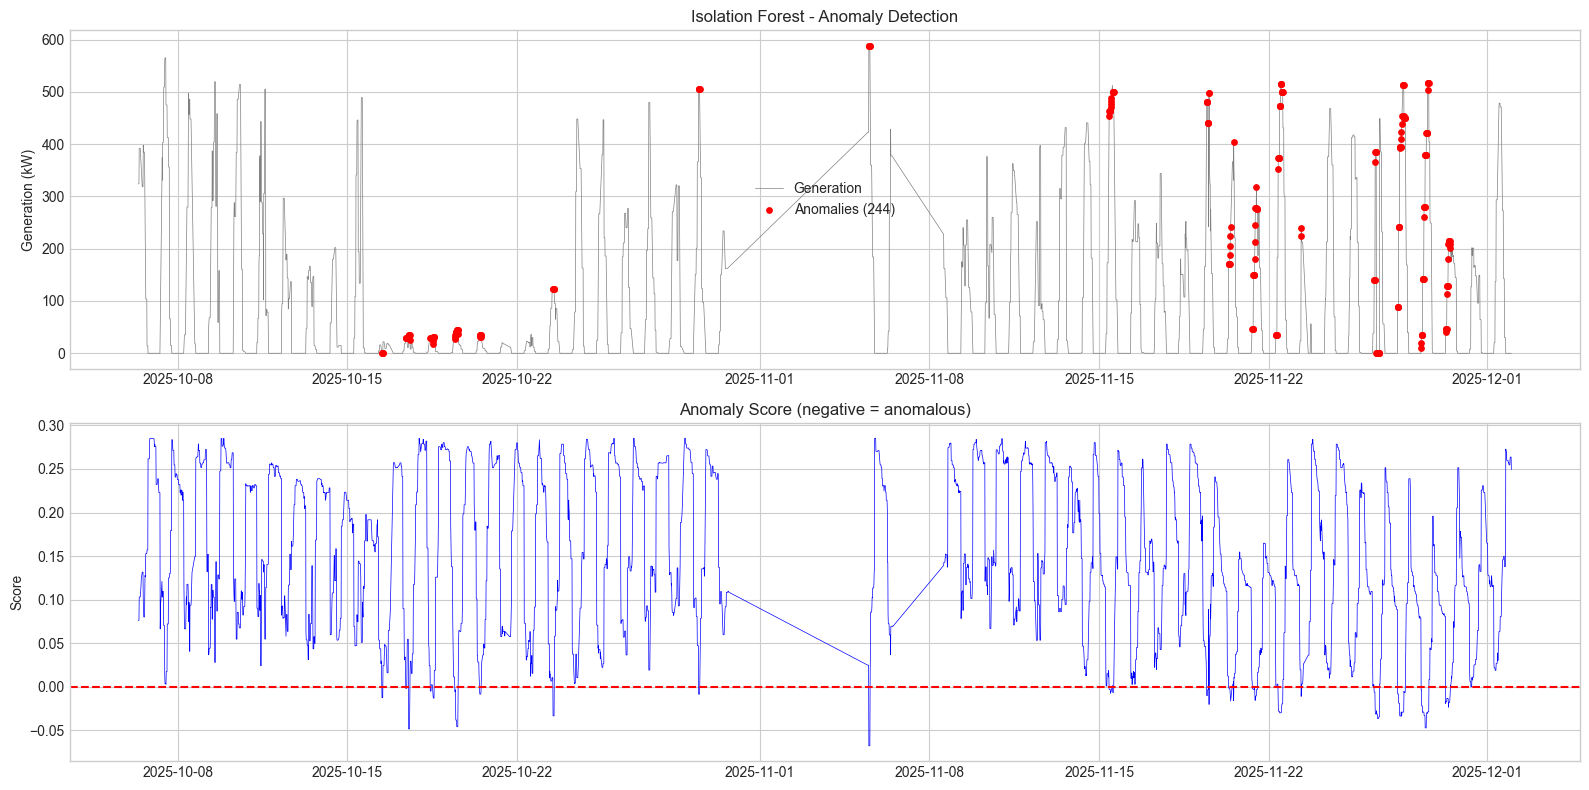

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(test_df.index, test_df[TARGET], color='gray', lw=0.5, label='Generation')
mask = iso_anomalies == 1
axes[0].scatter(test_df.index[mask], test_df[TARGET].values[mask],
               color='red', s=15, label=f'Anomalies ({mask.sum()})', zorder=5)
axes[0].set_title('Isolation Forest - Anomaly Detection')
axes[0].set_ylabel('Generation (kW)')
axes[0].legend()

axes[1].plot(test_df.index, iso_scores, color='blue', lw=0.5)
axes[1].axhline(y=0, color='red', ls='--')
axes[1].set_title('Anomaly Score (negative = anomalous)')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

## Model 2: Random Forest Regression

In [11]:
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=15,
    min_samples_split=5, random_state=42, n_jobs=-1
)
rf_model.fit(train_df[FEATURES], train_df[TARGET])
rf_preds = rf_model.predict(test_df[FEATURES])

rf_result = evaluate_model(test_df[TARGET].values, rf_preds, 'Random Forest')
all_results.append(rf_result)

importance = pd.DataFrame({'feature': FEATURES, 'importance': rf_model.feature_importances_})
print(f'\nFeature Importance:\n{importance.sort_values("importance", ascending=False)}')


=== Random Forest ===
  RMSE: 83.3744  MAE: 34.8012  R2: 0.6346

Feature Importance:
          feature  importance
0  irradiance_wm2    0.945821
1   temperature_c    0.054179


Random Forest anomalies: 159 (3.5%)


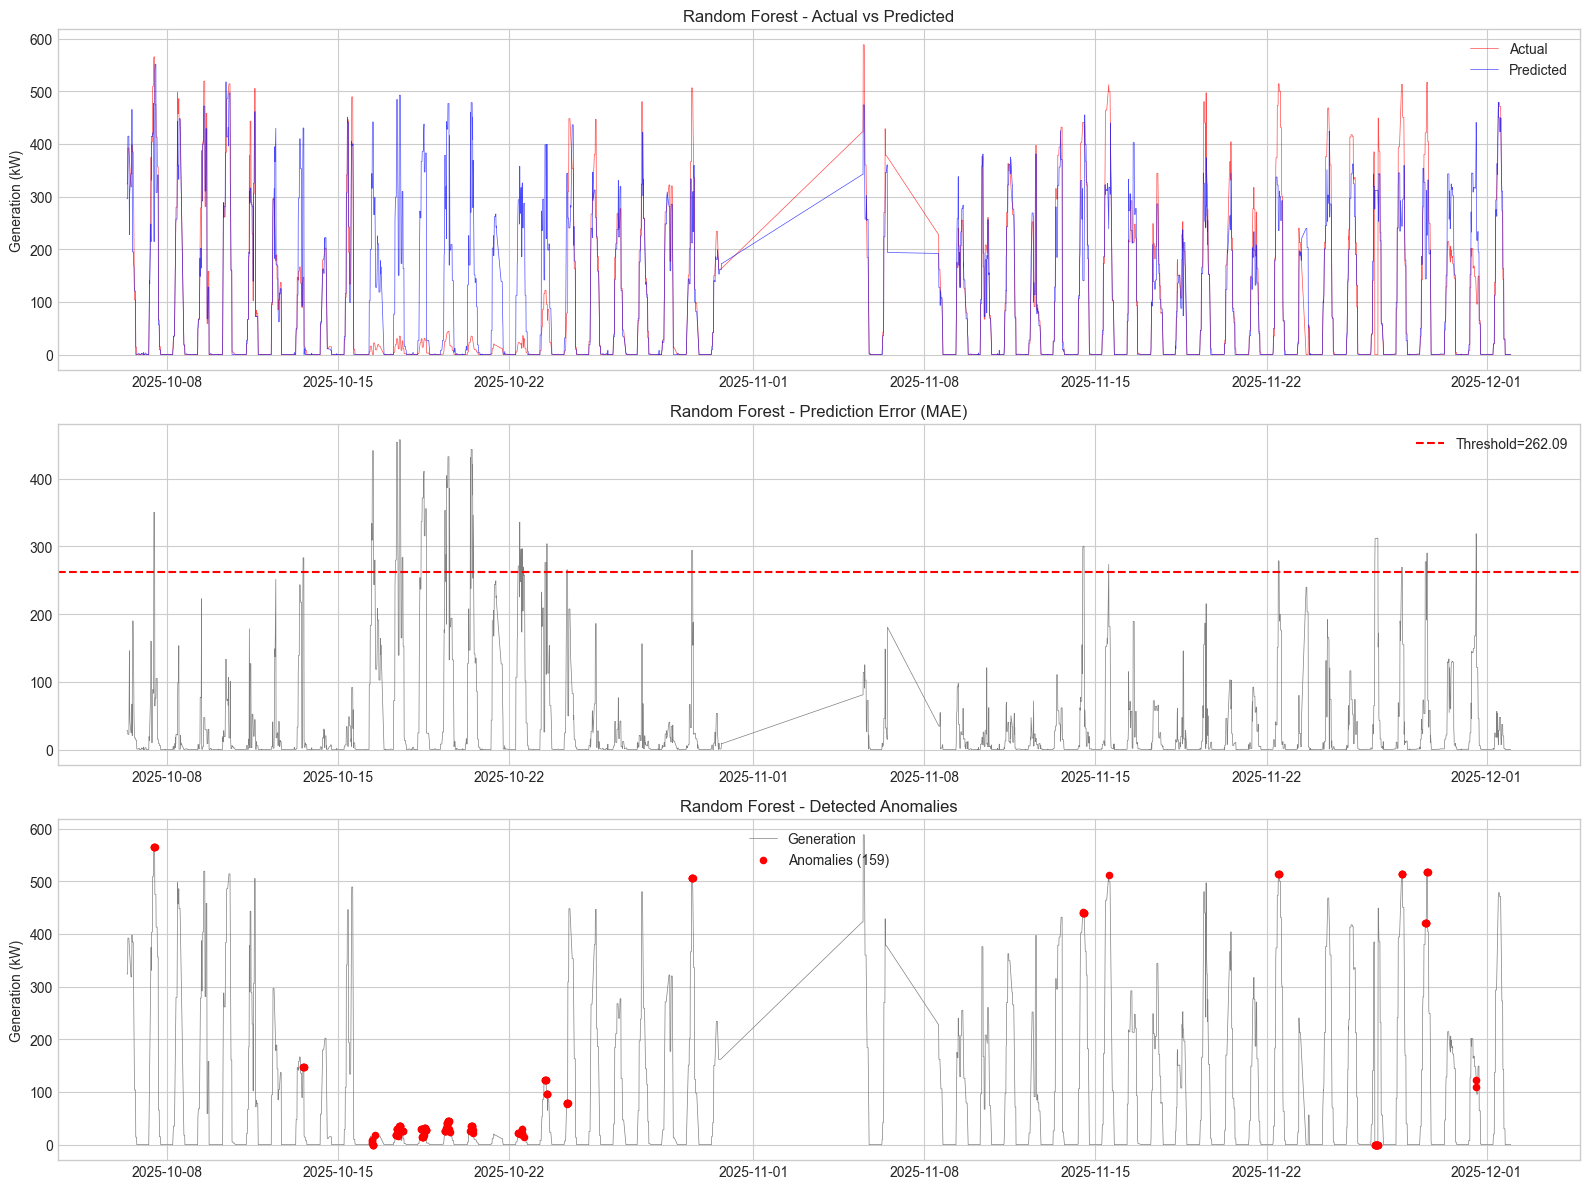

In [12]:
rf_mae, rf_threshold, rf_anomalies = detect_anomalies_3sigma(test_df[TARGET].values, rf_preds)
print(f'Random Forest anomalies: {rf_anomalies.sum()} ({rf_anomalies.sum()/len(rf_anomalies)*100:.1f}%)')
all_anomaly_counts['Random Forest'] = rf_anomalies.sum()

plot_anomalies(test_df.index, test_df[TARGET].values, rf_preds,
               rf_anomalies, 'Random Forest', rf_threshold)

---
# PART B: Deep Learning Models (PyTorch)
---

## Model 3: LSTM

In [13]:
class LSTMModel(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, n_features)
        )

    def forward(self, x):
        # x: (batch, timesteps, features)
        lstm_out, _ = self.lstm(x)
        # Take last timestep output
        out = self.fc(lstm_out[:, -1, :])
        return out


lstm_net = LSTMModel(N_FEATURES).to(device)
print(lstm_net)
print(f'Parameters: {sum(p.numel() for p in lstm_net.parameters()):,}')

LSTMModel(
  (lstm): LSTM(3, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=3, bias=True)
  )
)
Parameters: 53,123


Training LSTM...
  Epoch   1/100 | Train: 0.030106 | Val: 0.009925 | LR: 0.001000
  Epoch  10/100 | Train: 0.005135 | Val: 0.004417 | LR: 0.001000
  Epoch  20/100 | Train: 0.003341 | Val: 0.003261 | LR: 0.001000
  Epoch  30/100 | Train: 0.003138 | Val: 0.003174 | LR: 0.001000
  Epoch  40/100 | Train: 0.003173 | Val: 0.003378 | LR: 0.000500
  Epoch  50/100 | Train: 0.002950 | Val: 0.003139 | LR: 0.000250
  Epoch  60/100 | Train: 0.002942 | Val: 0.003092 | LR: 0.000250
  Epoch  70/100 | Train: 0.002998 | Val: 0.003131 | LR: 0.000125
  Epoch  80/100 | Train: 0.002892 | Val: 0.003070 | LR: 0.000063
  Epoch  90/100 | Train: 0.002841 | Val: 0.003076 | LR: 0.000016
  Early stopping at epoch 93
  Best val loss: 0.003061


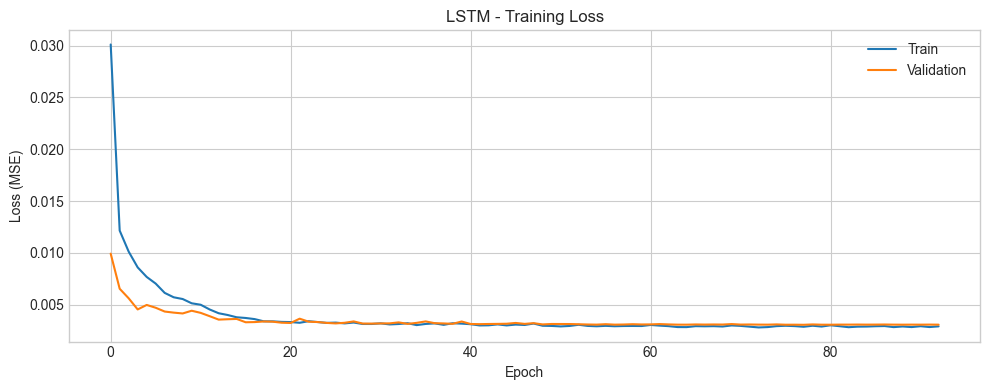

In [14]:
print('Training LSTM...')
lstm_net = train_model(lstm_net, train_loader, val_loader, name='LSTM')


=== LSTM ===
  RMSE: 32.4631  MAE: 15.4264  R2: 0.9445
LSTM anomalies: 102 (2.3%)


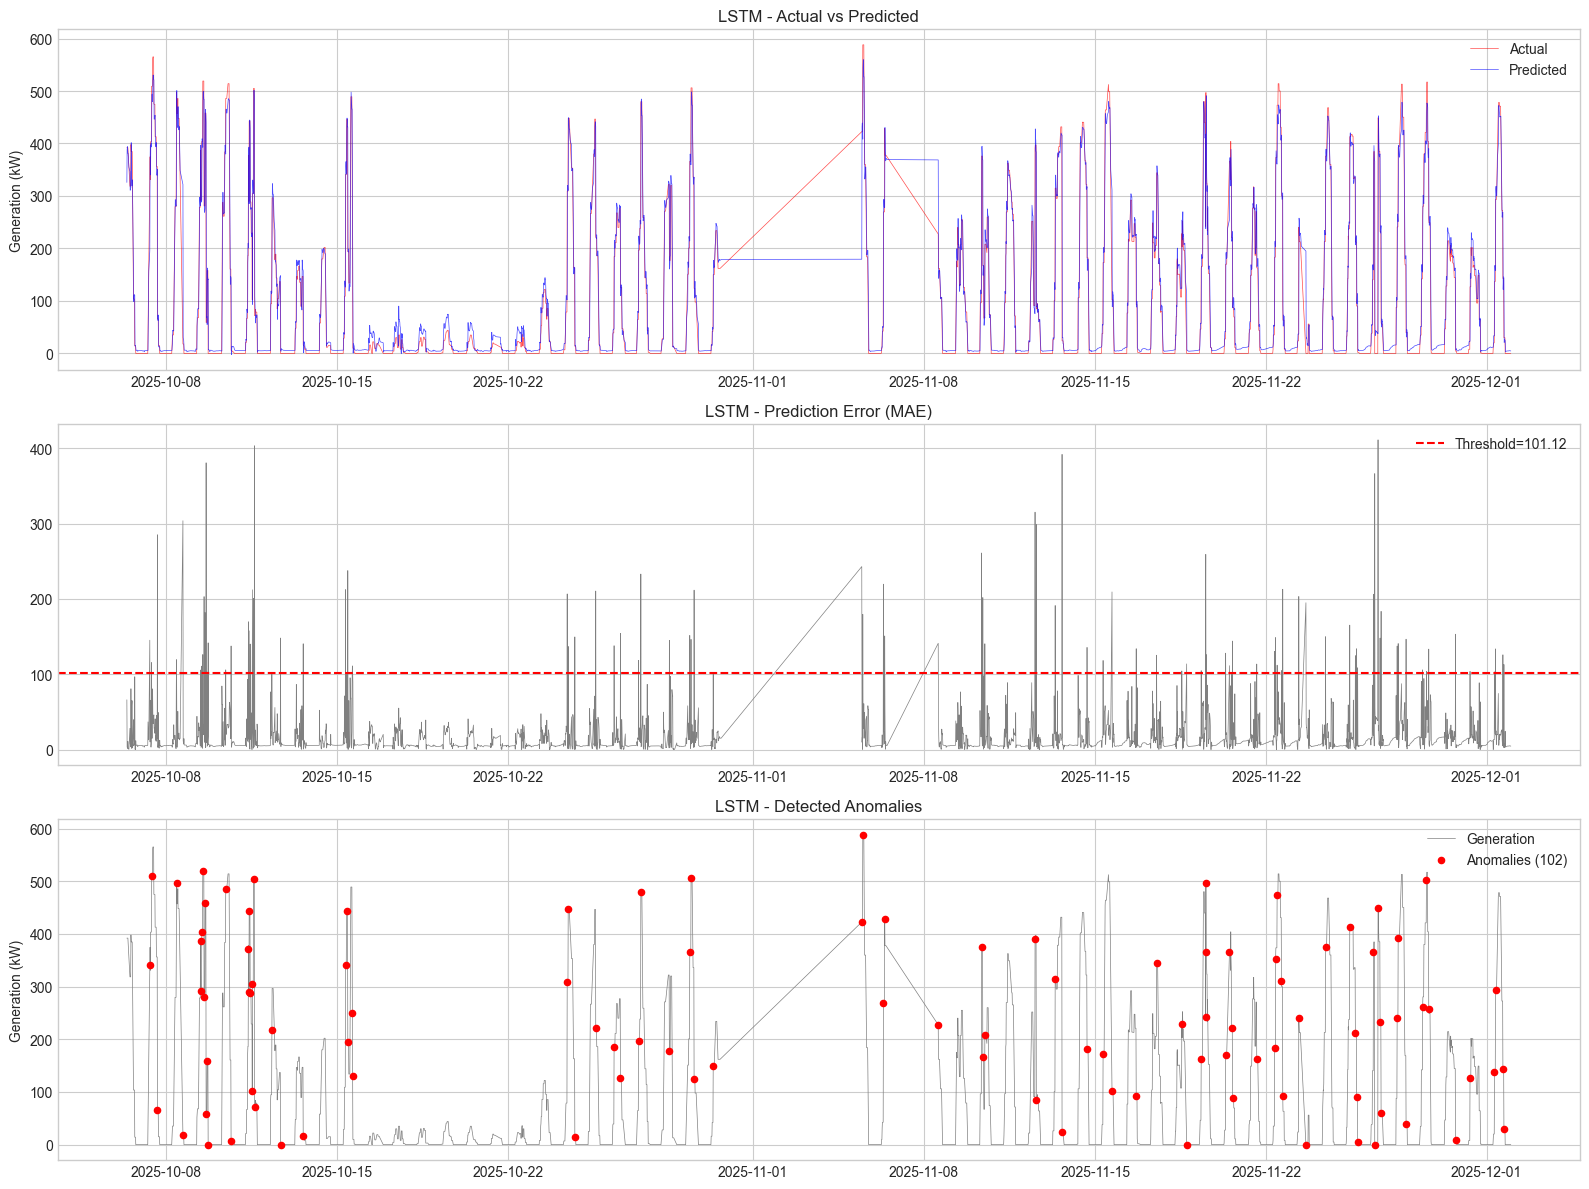

In [15]:
lstm_pred_scaled = predict(lstm_net, X_test_t)
lstm_pred = inverse_target(lstm_pred_scaled, scaler, N_FEATURES, TARGET_IDX)

lstm_result = evaluate_model(y_test_actual, lstm_pred, 'LSTM')
all_results.append(lstm_result)

lstm_mae, lstm_threshold, lstm_anomalies = detect_anomalies_3sigma(y_test_actual, lstm_pred)
print(f'LSTM anomalies: {lstm_anomalies.sum()} ({lstm_anomalies.sum()/len(lstm_anomalies)*100:.1f}%)')
all_anomaly_counts['LSTM'] = lstm_anomalies.sum()

plot_anomalies(test_timestamps, y_test_actual, lstm_pred,
               lstm_anomalies, 'LSTM', lstm_threshold)

## Model 4: CNN-LSTM

In [16]:
class CNNLSTM(nn.Module):
    def __init__(self, n_features, cnn_filters=32, lstm_hidden=32, dropout=0.2):
        super().__init__()
        # CNN: expects (batch, channels, seq_len) -> permute input
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=n_features, out_channels=cnn_filters,
                      kernel_size=2, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=cnn_filters, out_channels=16,
                      kernel_size=2, padding=1),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(
            input_size=16,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True,
            dropout=0
        )
        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, n_features)
        )

    def forward(self, x):
        # x: (batch, timesteps, features)
        # CNN expects (batch, features, timesteps)
        x_cnn = x.permute(0, 2, 1)
        cnn_out = self.cnn(x_cnn)           # (batch, 16, seq)
        cnn_out = cnn_out.permute(0, 2, 1)  # (batch, seq, 16)
        lstm_out, _ = self.lstm(cnn_out)
        out = self.fc(lstm_out[:, -1, :])
        return out


cnn_lstm_net = CNNLSTM(N_FEATURES).to(device)
print(cnn_lstm_net)
print(f'Parameters: {sum(p.numel() for p in cnn_lstm_net.parameters()):,}')

CNNLSTM(
  (cnn): Sequential(
    (0): Conv1d(3, 32, kernel_size=(2,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(32, 16, kernel_size=(2,), stride=(1,), padding=(1,))
    (3): ReLU()
  )
  (lstm): LSTM(16, 32, batch_first=True)
  (fc): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=3, bias=True)
  )
)
Parameters: 8,819


Training CNN-LSTM...
  Epoch   1/100 | Train: 0.033263 | Val: 0.006264 | LR: 0.001000
  Epoch  10/100 | Train: 0.004491 | Val: 0.003513 | LR: 0.001000
  Epoch  20/100 | Train: 0.003339 | Val: 0.003195 | LR: 0.000500
  Epoch  30/100 | Train: 0.003038 | Val: 0.003132 | LR: 0.000500
  Epoch  40/100 | Train: 0.003072 | Val: 0.003078 | LR: 0.000250
  Epoch  50/100 | Train: 0.003018 | Val: 0.003062 | LR: 0.000063
  Epoch  60/100 | Train: 0.003146 | Val: 0.003072 | LR: 0.000031
  Early stopping at epoch 69
  Best val loss: 0.003053


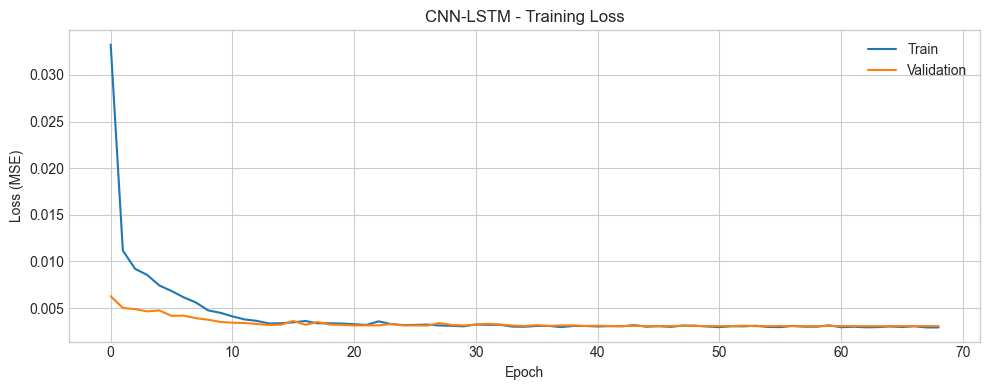

In [17]:
print('Training CNN-LSTM...')
cnn_lstm_net = train_model(cnn_lstm_net, train_loader, val_loader, name='CNN-LSTM')


=== CNN-LSTM ===
  RMSE: 32.8658  MAE: 15.4541  R2: 0.9431
CNN-LSTM anomalies: 94 (2.1%)


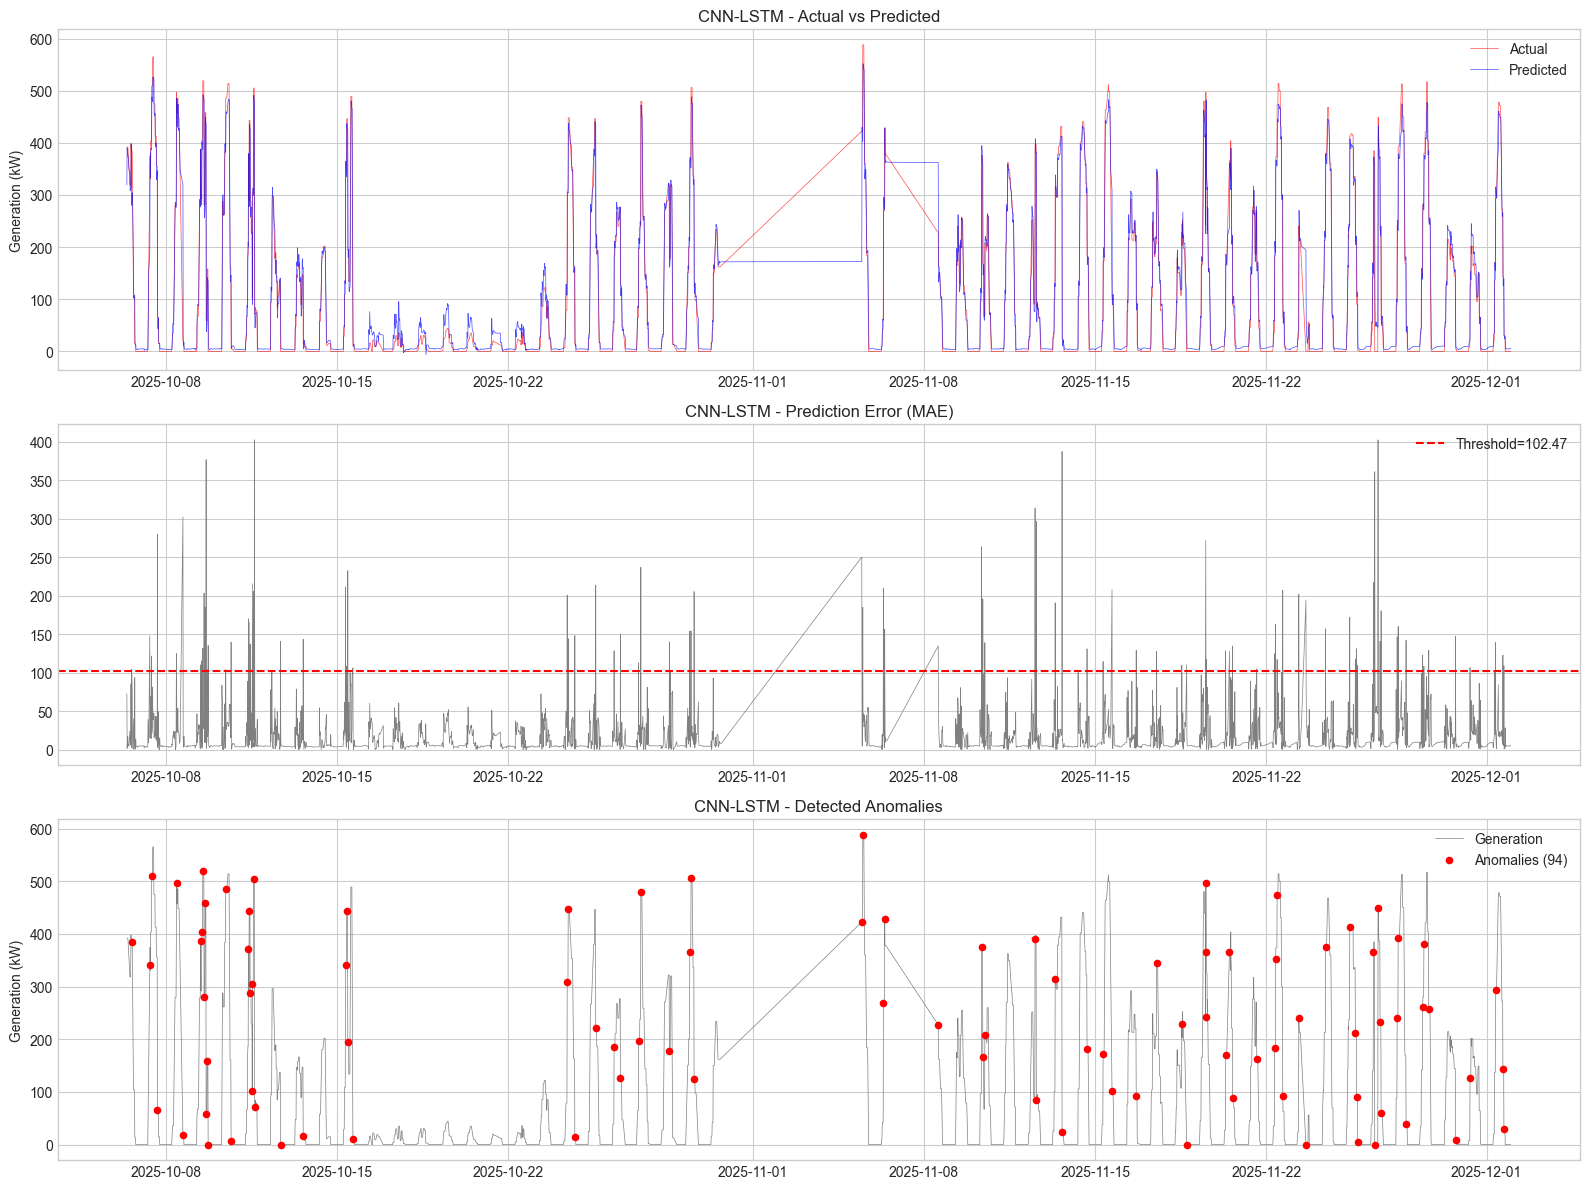

In [18]:
cnn_lstm_pred_scaled = predict(cnn_lstm_net, X_test_t)
cnn_lstm_pred = inverse_target(cnn_lstm_pred_scaled, scaler, N_FEATURES, TARGET_IDX)

cnn_lstm_result = evaluate_model(y_test_actual, cnn_lstm_pred, 'CNN-LSTM')
all_results.append(cnn_lstm_result)

cl_mae, cl_threshold, cl_anomalies = detect_anomalies_3sigma(y_test_actual, cnn_lstm_pred)
print(f'CNN-LSTM anomalies: {cl_anomalies.sum()} ({cl_anomalies.sum()/len(cl_anomalies)*100:.1f}%)')
all_anomaly_counts['CNN-LSTM'] = cl_anomalies.sum()

plot_anomalies(test_timestamps, y_test_actual, cnn_lstm_pred,
               cl_anomalies, 'CNN-LSTM', cl_threshold)

## Model 5: LSTM Autoencoder (Reconstruction-Based)

In [19]:
class LSTMAutoencoder(nn.Module):
    """LSTM Autoencoder: learns to reconstruct normal sequences.
    Anomalies produce high reconstruction error."""

    def __init__(self, n_features, hidden_enc=32, hidden_bottleneck=16,
                 timesteps=4, dropout=0.2):
        super().__init__()
        self.timesteps = timesteps
        self.hidden_bottleneck = hidden_bottleneck

        # Encoder
        self.encoder_lstm1 = nn.LSTM(n_features, hidden_enc, batch_first=True)
        self.encoder_dropout = nn.Dropout(dropout)
        self.encoder_lstm2 = nn.LSTM(hidden_enc, hidden_bottleneck, batch_first=True)

        # Decoder
        self.decoder_lstm1 = nn.LSTM(hidden_bottleneck, hidden_bottleneck, batch_first=True)
        self.decoder_dropout = nn.Dropout(dropout)
        self.decoder_lstm2 = nn.LSTM(hidden_bottleneck, hidden_enc, batch_first=True)
        self.output_layer = nn.Linear(hidden_enc, n_features)

    def forward(self, x):
        # Encode: (batch, timesteps, features) -> (batch, hidden_bottleneck)
        enc, _ = self.encoder_lstm1(x)
        enc = self.encoder_dropout(enc)
        enc, _ = self.encoder_lstm2(enc)
        # Take the last timestep as bottleneck
        bottleneck = enc[:, -1, :]  # (batch, hidden_bottleneck)

        # Decode: repeat bottleneck for each timestep
        dec_input = bottleneck.unsqueeze(1).repeat(1, self.timesteps, 1)
        dec, _ = self.decoder_lstm1(dec_input)
        dec = self.decoder_dropout(dec)
        dec, _ = self.decoder_lstm2(dec)
        out = self.output_layer(dec)  # (batch, timesteps, features)
        return out


ae_net = LSTMAutoencoder(N_FEATURES, timesteps=TIMESTEPS).to(device)
print(ae_net)
print(f'Parameters: {sum(p.numel() for p in ae_net.parameters()):,}')

LSTMAutoencoder(
  (encoder_lstm1): LSTM(3, 32, batch_first=True)
  (encoder_dropout): Dropout(p=0.2, inplace=False)
  (encoder_lstm2): LSTM(32, 16, batch_first=True)
  (decoder_lstm1): LSTM(16, 16, batch_first=True)
  (decoder_dropout): Dropout(p=0.2, inplace=False)
  (decoder_lstm2): LSTM(16, 32, batch_first=True)
  (output_layer): Linear(in_features=32, out_features=3, bias=True)
)
Parameters: 16,611


Training LSTM Autoencoder...
  Epoch   1/100 | Train: 0.077290 | Val: 0.011938 | LR: 0.001000
  Epoch  10/100 | Train: 0.003184 | Val: 0.002945 | LR: 0.001000
  Epoch  20/100 | Train: 0.001219 | Val: 0.001084 | LR: 0.001000
  Epoch  30/100 | Train: 0.000939 | Val: 0.000819 | LR: 0.001000
  Epoch  40/100 | Train: 0.000792 | Val: 0.000731 | LR: 0.001000
  Epoch  50/100 | Train: 0.000651 | Val: 0.000493 | LR: 0.001000
  Epoch  60/100 | Train: 0.000545 | Val: 0.000437 | LR: 0.000500
  Epoch  70/100 | Train: 0.000522 | Val: 0.000423 | LR: 0.000500
  Epoch  80/100 | Train: 0.000493 | Val: 0.000364 | LR: 0.000250
  Epoch  90/100 | Train: 0.000472 | Val: 0.000351 | LR: 0.000125
  Epoch 100/100 | Train: 0.000475 | Val: 0.000357 | LR: 0.000125
  Best val loss: 0.000345


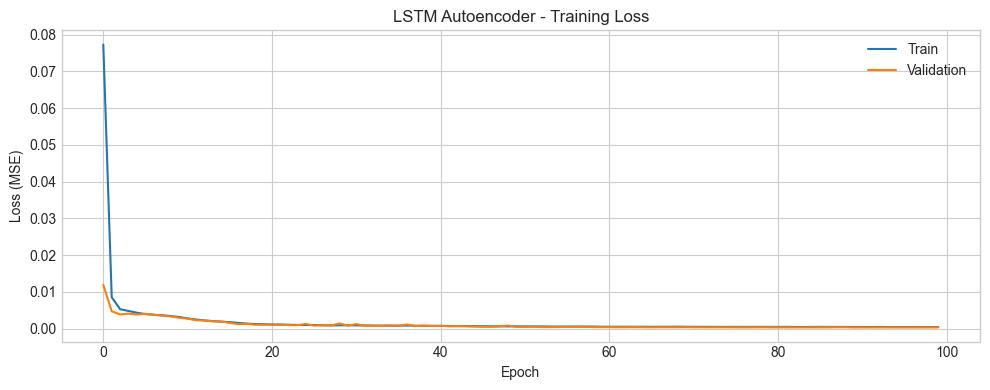

In [20]:
# Autoencoder: target = input (reconstruct the sequence)
ae_train_loader = DataLoader(TensorDataset(X_tr_t, X_tr_t), batch_size=BATCH_SIZE, shuffle=True)
ae_val_loader = DataLoader(TensorDataset(X_val_t, X_val_t), batch_size=BATCH_SIZE)

print('Training LSTM Autoencoder...')
ae_net = train_model(ae_net, ae_train_loader, ae_val_loader, name='LSTM Autoencoder')

LSTM Autoencoder anomalies: 265 (5.9%)


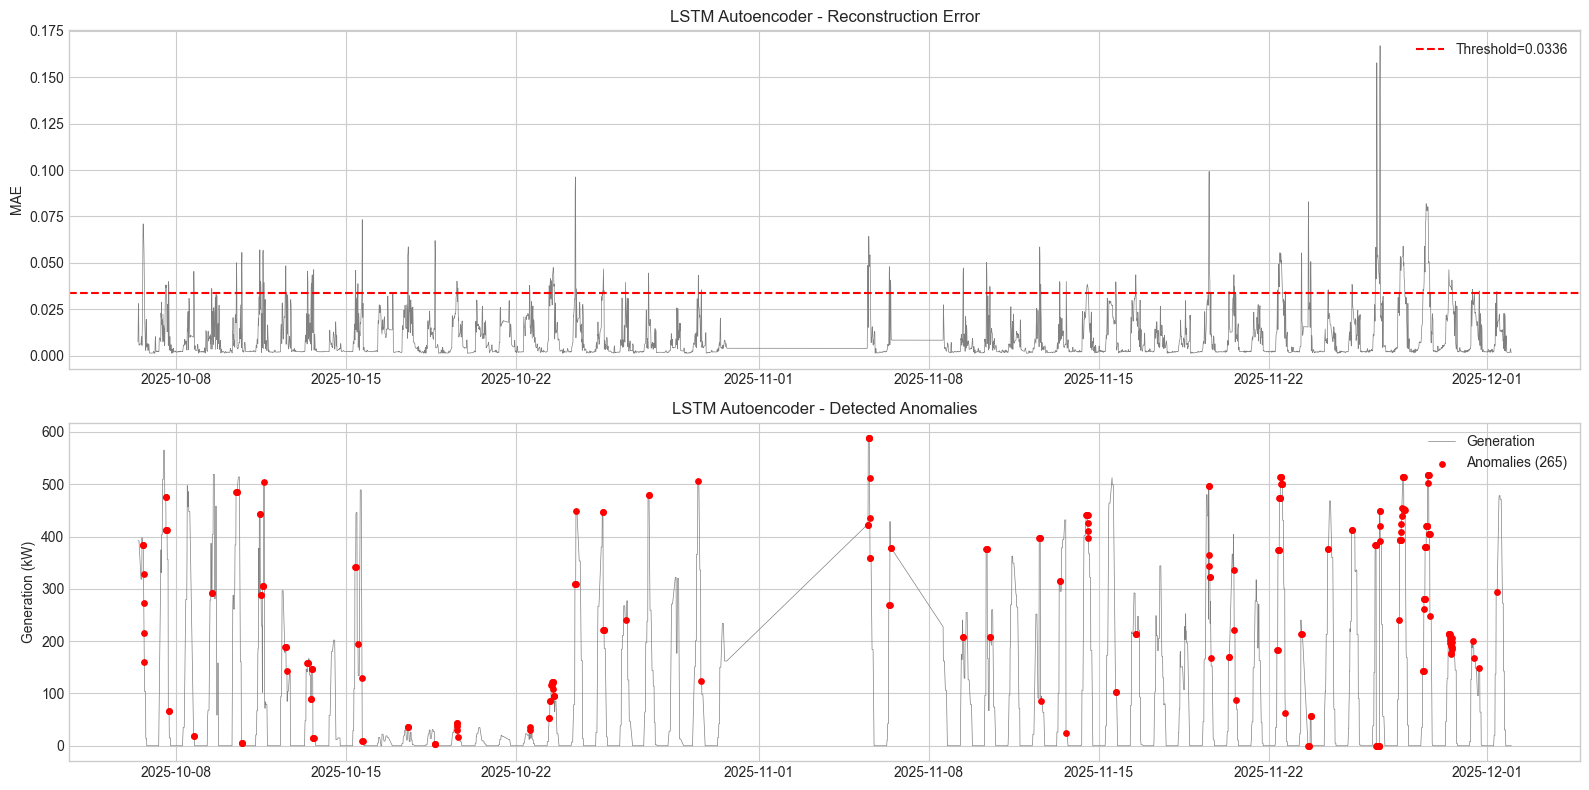

In [21]:
# Compute reconstruction error
ae_test_recon = predict(ae_net, X_test_t)
ae_recon_error = np.mean(np.abs(X_test_np - ae_test_recon), axis=(1, 2))

# Threshold from training data
ae_train_recon = predict(ae_net, X_tr_t)
ae_train_error = np.mean(np.abs(X_tr - ae_train_recon), axis=(1, 2))
ae_threshold = ae_train_error.mean() + 3 * ae_train_error.std()

ae_anomalies = (ae_recon_error > ae_threshold).astype(int)
print(f'LSTM Autoencoder anomalies: {ae_anomalies.sum()} ({ae_anomalies.sum()/len(ae_anomalies)*100:.1f}%)')
all_anomaly_counts['LSTM Autoencoder'] = ae_anomalies.sum()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(test_timestamps, ae_recon_error, color='gray', lw=0.5)
axes[0].axhline(ae_threshold, color='red', ls='--', label=f'Threshold={ae_threshold:.4f}')
axes[0].set_title('LSTM Autoencoder - Reconstruction Error')
axes[0].set_ylabel('MAE')
axes[0].legend()

axes[1].plot(test_timestamps, y_test_actual, color='gray', lw=0.5, label='Generation')
mask = ae_anomalies == 1
if mask.sum() > 0:
    axes[1].scatter(test_timestamps[mask], y_test_actual[mask],
                   c='red', s=15, zorder=5, label=f'Anomalies ({mask.sum()})')
axes[1].set_title('LSTM Autoencoder - Detected Anomalies')
axes[1].set_ylabel('Generation (kW)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Model 6: Transformer

In [22]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding for Transformer."""
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model > 1:
            pe[:, 1::2] = torch.cos(position * div_term[:d_model // 2])
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TransformerModel(nn.Module):
    def __init__(self, n_features, d_model=32, nhead=2, num_layers=2,
                 dim_feedforward=64, dropout=0.1):
        super().__init__()
        self.input_projection = nn.Linear(n_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.fc = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_features)
        )

    def forward(self, x):
        # x: (batch, timesteps, features)
        x = self.input_projection(x)        # (batch, timesteps, d_model)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)     # (batch, timesteps, d_model)
        # Global average pooling over timesteps
        x = x.mean(dim=1)                   # (batch, d_model)
        out = self.fc(x)                    # (batch, n_features)
        return out


transformer_net = TransformerModel(N_FEATURES).to(device)
print(transformer_net)
print(f'Parameters: {sum(p.numel() for p in transformer_net.parameters()):,}')

TransformerModel(
  (input_projection): Linear(in_features=3, out_features=32, bias=True)
  (pos_encoder): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=

Training Transformer...
  Epoch   1/100 | Train: 0.011664 | Val: 0.005691 | LR: 0.001000
  Epoch  10/100 | Train: 0.002915 | Val: 0.003373 | LR: 0.001000
  Epoch  20/100 | Train: 0.002426 | Val: 0.003267 | LR: 0.001000
  Epoch  30/100 | Train: 0.002191 | Val: 0.003096 | LR: 0.000250
  Epoch  40/100 | Train: 0.002059 | Val: 0.003026 | LR: 0.000125
  Epoch  50/100 | Train: 0.002096 | Val: 0.003024 | LR: 0.000063
  Epoch  60/100 | Train: 0.002088 | Val: 0.003005 | LR: 0.000063
  Epoch  70/100 | Train: 0.002001 | Val: 0.002994 | LR: 0.000031
  Epoch  80/100 | Train: 0.002026 | Val: 0.002985 | LR: 0.000016
  Epoch  90/100 | Train: 0.002040 | Val: 0.002985 | LR: 0.000004
  Early stopping at epoch 93
  Best val loss: 0.002983


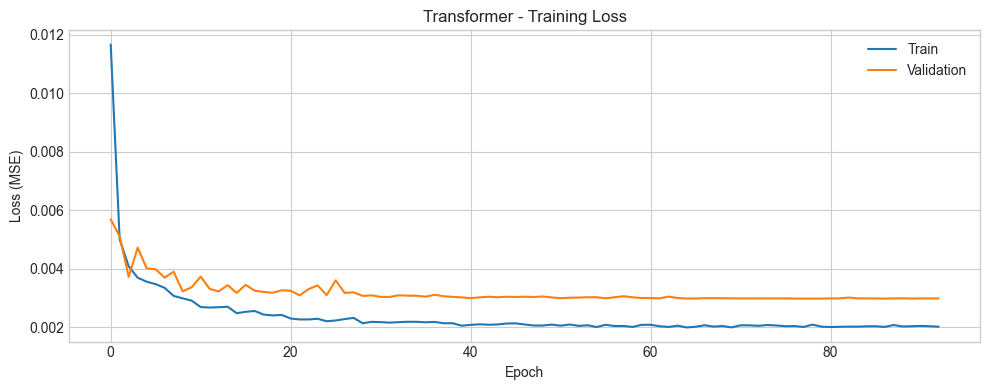

In [23]:
print('Training Transformer...')
transformer_net = train_model(transformer_net, train_loader, val_loader, name='Transformer')


=== Transformer ===
  RMSE: 32.0515  MAE: 13.7567  R2: 0.9459
Transformer anomalies: 100 (2.2%)


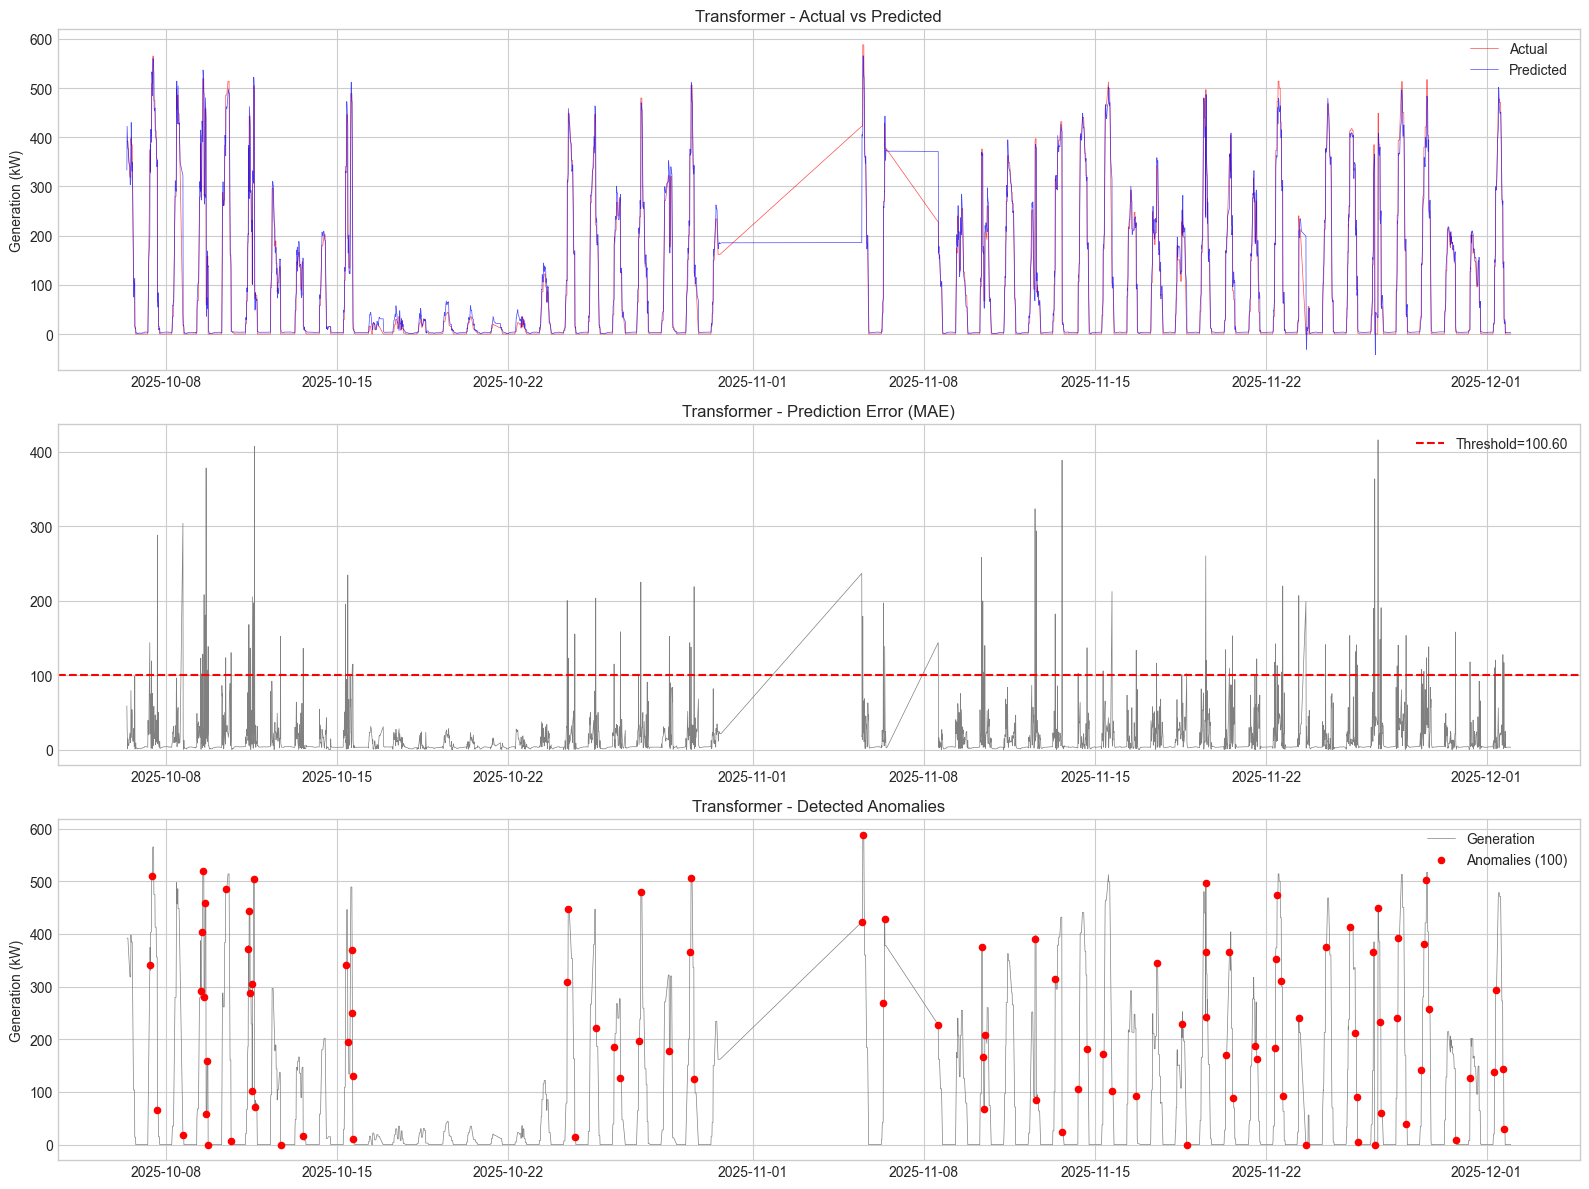

In [24]:
tf_pred_scaled = predict(transformer_net, X_test_t)
tf_pred = inverse_target(tf_pred_scaled, scaler, N_FEATURES, TARGET_IDX)

tf_result = evaluate_model(y_test_actual, tf_pred, 'Transformer')
all_results.append(tf_result)

tf_mae, tf_threshold, tf_anomalies = detect_anomalies_3sigma(y_test_actual, tf_pred)
print(f'Transformer anomalies: {tf_anomalies.sum()} ({tf_anomalies.sum()/len(tf_anomalies)*100:.1f}%)')
all_anomaly_counts['Transformer'] = tf_anomalies.sum()

plot_anomalies(test_timestamps, y_test_actual, tf_pred,
               tf_anomalies, 'Transformer', tf_threshold)

---
# PART C: Model Comparison & Ensemble
---

=== Model Comparison (Prediction Quality) ===
                  RMSE      MAE      R2
model                                  
Random Forest  83.3744  34.8012  0.6346
LSTM           32.4631  15.4264  0.9445
CNN-LSTM       32.8658  15.4541  0.9431
Transformer    32.0515  13.7567  0.9459


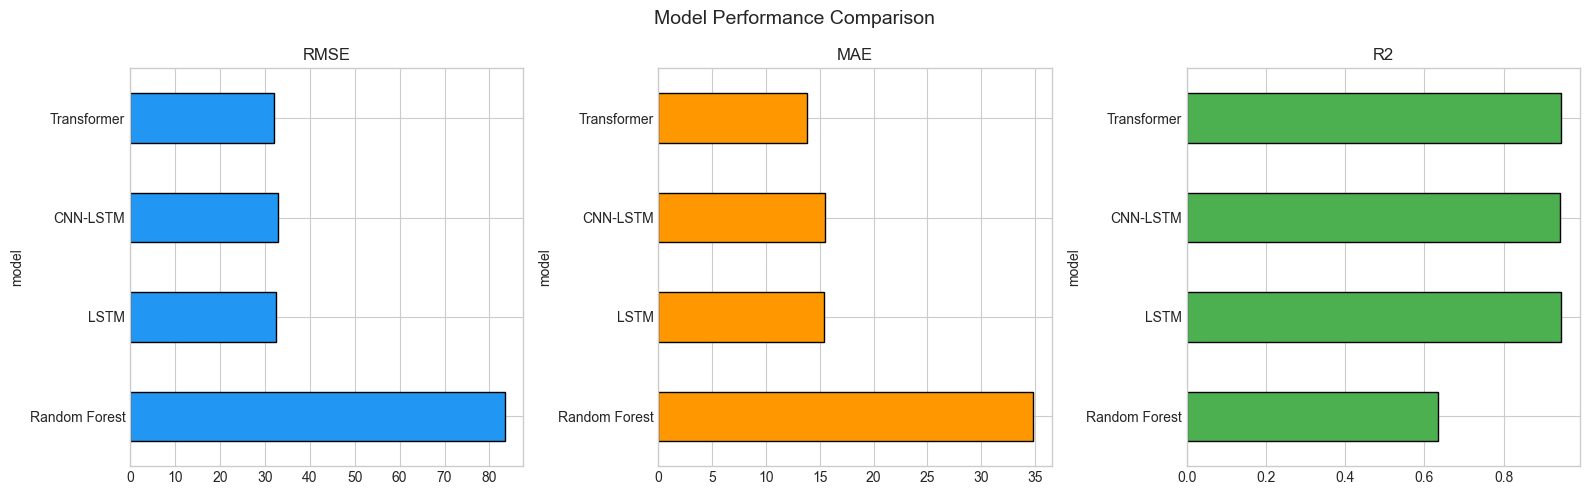

In [25]:
results_df = pd.DataFrame(all_results).set_index('model')
print('=== Model Comparison (Prediction Quality) ===')
print(results_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, color in zip(axes, ['RMSE', 'MAE', 'R2'],
                              ['#2196F3', '#FF9800', '#4CAF50']):
    results_df[metric].plot(kind='barh', ax=ax, color=color, edgecolor='black')
    ax.set_title(metric)

plt.suptitle('Model Performance Comparison', fontsize=14)
plt.tight_layout()
plt.show()


=== Anomaly Counts ===
              model  anomalies
0  Isolation Forest        244
1     Random Forest        159
2              LSTM        102
3          CNN-LSTM         94
4  LSTM Autoencoder        265
5       Transformer        100


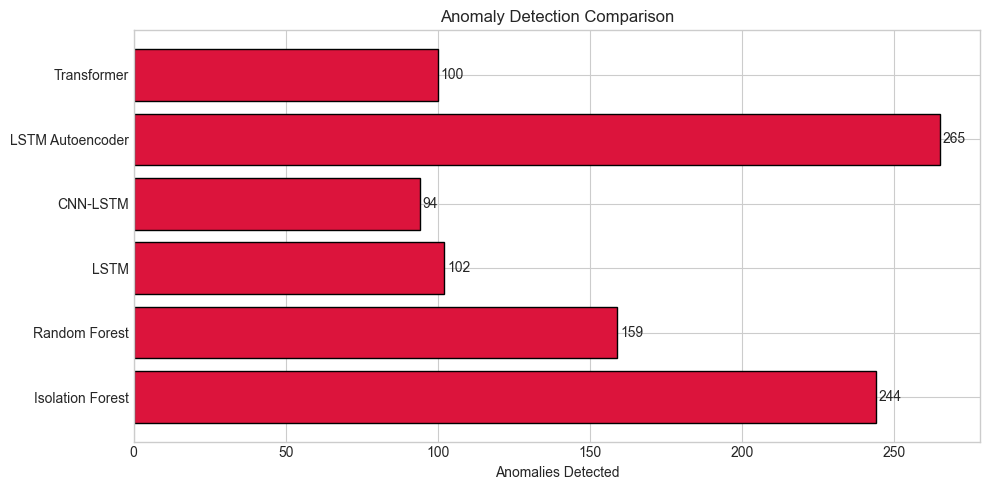

In [26]:
print('\n=== Anomaly Counts ===')
anomaly_df = pd.DataFrame(list(all_anomaly_counts.items()), columns=['model', 'anomalies'])
print(anomaly_df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(anomaly_df['model'], anomaly_df['anomalies'], color='crimson', edgecolor='black')
ax.set_xlabel('Anomalies Detected')
ax.set_title('Anomaly Detection Comparison')
for i, v in enumerate(anomaly_df['anomalies']):
    ax.text(v + 1, i, str(v), va='center')
plt.tight_layout()
plt.show()

## Ensemble Anomaly Detection

Flag a point as anomaly if **>= 3 of 6 models** agree.

In [27]:
n = len(test_timestamps)

# Align all to same length
iso_aligned = iso_anomalies[TIMESTEPS:TIMESTEPS + n]
rf_aligned = rf_anomalies[TIMESTEPS:TIMESTEPS + n]

ensemble_matrix = np.column_stack([
    iso_aligned, rf_aligned,
    lstm_anomalies[:n], cl_anomalies[:n],
    ae_anomalies[:n], tf_anomalies[:n]
])

ensemble_votes = ensemble_matrix.sum(axis=1)
ensemble_anomalies = (ensemble_votes >= 3).astype(int)

print(f'Ensemble anomalies (majority >= 3): {ensemble_anomalies.sum()}')
print('Vote distribution:')
for v in range(7):
    c = (ensemble_votes == v).sum()
    if c > 0:
        print(f'  {v} models agree: {c} points')

Ensemble anomalies (majority >= 3): 131
Vote distribution:
  0 models agree: 3939 points
  1 models agree: 311 points
  2 models agree: 119 points
  3 models agree: 114 points
  4 models agree: 13 points
  5 models agree: 3 points
  6 models agree: 1 points


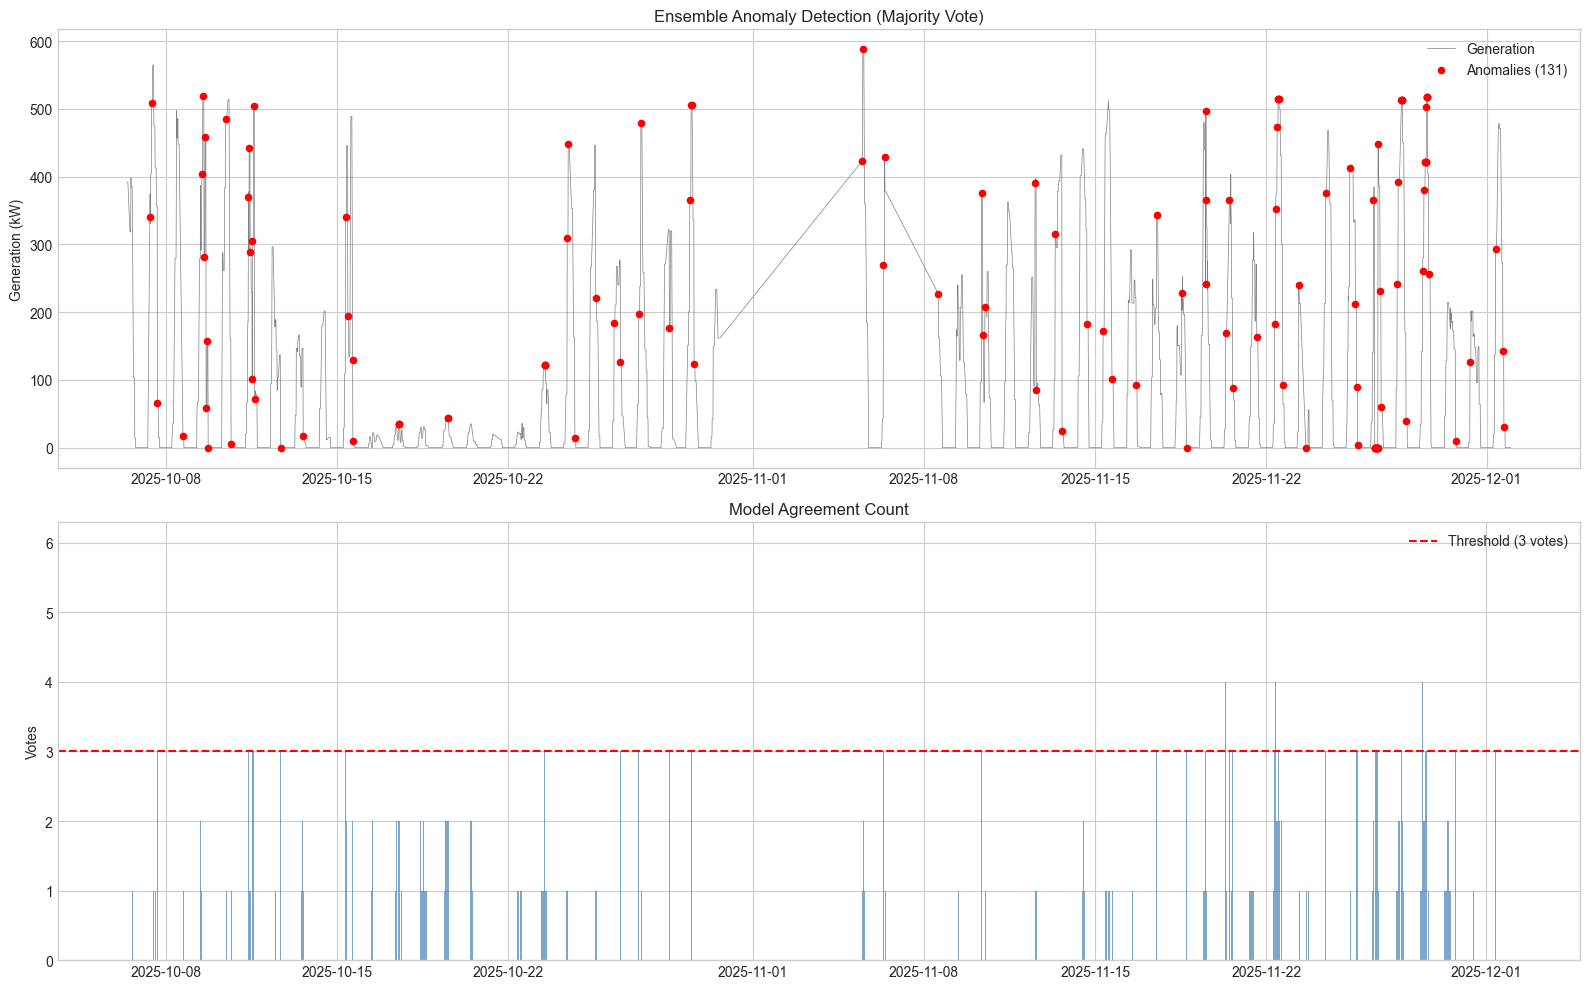

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(test_timestamps[:n], y_test_actual[:n], color='gray', lw=0.5, label='Generation')
mask = ensemble_anomalies == 1
if mask.sum() > 0:
    axes[0].scatter(test_timestamps[:n][mask], y_test_actual[:n][mask],
                   c='red', s=20, zorder=5, label=f'Anomalies ({mask.sum()})')
axes[0].set_title('Ensemble Anomaly Detection (Majority Vote)')
axes[0].set_ylabel('Generation (kW)')
axes[0].legend()

axes[1].bar(test_timestamps[:n], ensemble_votes, color='steelblue', width=0.01, alpha=0.7)
axes[1].axhline(3, color='red', ls='--', label='Threshold (3 votes)')
axes[1].set_title('Model Agreement Count')
axes[1].set_ylabel('Votes')
axes[1].legend()

plt.tight_layout()
plt.show()

## Save Models

In [29]:
import os
import joblib

MODEL_DIR = 'models/'
os.makedirs(MODEL_DIR, exist_ok=True)

# Save sklearn models
joblib.dump(iso_forest, MODEL_DIR + 'isolation_forest.joblib')
joblib.dump(rf_model, MODEL_DIR + 'random_forest.joblib')
joblib.dump(scaler, MODEL_DIR + 'scaler.joblib')

# Save PyTorch models
torch.save(lstm_net.state_dict(), MODEL_DIR + 'lstm_model.pt')
torch.save(cnn_lstm_net.state_dict(), MODEL_DIR + 'cnn_lstm_model.pt')
torch.save(ae_net.state_dict(), MODEL_DIR + 'lstm_autoencoder.pt')
torch.save(transformer_net.state_dict(), MODEL_DIR + 'transformer_model.pt')

# Save model configs for reloading
model_configs = {
    'n_features': N_FEATURES,
    'timesteps': TIMESTEPS,
    'target_idx': TARGET_IDX,
    'all_cols': ALL_COLS,
    'features': FEATURES,
    'target': TARGET,
}
joblib.dump(model_configs, MODEL_DIR + 'model_configs.joblib')

print('All models saved to models/')
print(os.listdir(MODEL_DIR))

All models saved to models/
['cnn_lstm_model.pt', 'isolation_forest.joblib', 'lstm_autoencoder.pt', 'lstm_model.pt', 'model_configs.joblib', 'random_forest.joblib', 'scaler.joblib', 'transformer_model.pt']


## Loading Models (for inference on other sites)

```python
# Example: reload LSTM model
configs = joblib.load('models/model_configs.joblib')
scaler = joblib.load('models/scaler.joblib')

model = LSTMModel(configs['n_features']).to(device)
model.load_state_dict(torch.load('models/lstm_model.pt'))
model.eval()

# Predict on new data
new_data_scaled = scaler.transform(new_df[configs['all_cols']])
X_new, _ = create_sequences(new_data_scaled, configs['timesteps'])
X_new_t = torch.FloatTensor(X_new).to(device)
preds = predict(model, X_new_t)
```

## Summary

| Model | Type | Framework | Anomaly Method |
|-------|------|-----------|----------------|
| Isolation Forest | ML Unsupervised | sklearn | Isolation score |
| Random Forest | ML Supervised | sklearn | 3-sigma on prediction MAE |
| LSTM | DL Sequential | **PyTorch** | 3-sigma on prediction MAE |
| CNN-LSTM | DL Hybrid | **PyTorch** | 3-sigma on prediction MAE |
| LSTM Autoencoder | DL Reconstruction | **PyTorch** | 3-sigma on reconstruction error |
| Transformer | DL Attention | **PyTorch** | 3-sigma on prediction MAE |

### Next Steps
- Extend to all 4 sites
- Tune sigma threshold per site
- Add anomaly type classification
- Build real-time monitoring pipeline